In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sc

# Hypothesis testing in python

>A hypothesis is a statement about n unkmown population parameter.

- A hypothesis test is a test of two competing hypotheses:
    1. Null hypothesis $(H_0)$ is an existing idea
    2. Alternative hypothesis $(H_A)$ is the new 'challenger' idea

- Either $(H_0)$ OR $(H_A)$ can be true (not both)

- Initially $(H_0)$ is assumed to be true unless proven false by $(H_A)$

_When you have eliminated the impossible, whatever remains, however improbable, must be the truth" —(Sherlock Holmes, The Sign of Four)_

## Hypothesis fundamentals
Loading a salary survey dataset from StackOverflow. All survey participants have a data scientist OR a DS-adjacent role.

>Hypothesis: that mean annual consumption of data scientists is $11000

We'll now implement certain steps to validate this hypothesis.

### Hypothesis testing
>**The goal of hypothesis testing is to determine whether there is enough statistical evidence to reject the null hypothesis in favor of the alternate hypothesis.**

In [2]:
# loading data of salary survey by stackoverflow
stackoverflowdf = pd.read_feather('./datasets/stack_overflow.feather')
stackoverflowdf.head(2)

,respondent,main_branch,hobbyist,age,age_1st_code,age_first_code_cut,comp_freq,comp_total,converted_comp,country,...,survey_length,trans,undergrad_major,webframe_desire_next_year,webframe_worked_with,welcome_change,work_week_hrs,years_code,years_code_pro,age_cat
0,36.0,"I am not primarily a developer, but I write co...",Yes,34.0,30.0,adult,Yearly,60000.0,77556.0,United Kingdom,...,Appropriate in length,No,"Computer science, computer engineering, or sof...",Express;React.js,Express;React.js,Just as welcome now as I felt last year,40.0,4.0,3.0,At least 30
1,47.0,I am a developer by profession,Yes,53.0,10.0,child,Yearly,58000.0,74970.0,United Kingdom,...,Appropriate in length,No,"A natural science (such as biology, chemistry,...",Flask;Spring,Flask;Spring,Just as welcome now as I felt last year,40.0,43.0,28.0,At least 30


In [3]:
mean_comp_sample = stackoverflowdf["converted_comp"].mean()
print(f"Overall mean annual compensation is : {mean_comp_sample}")

Overall mean annual compensation is : 119574.71738168952


>We observe that mean of all compensation is different from our hypothesis. 
>
>Now we'll work to determine how significant is this difference from the true mean.

- We'll be generating several bootstrapped-samples (~5K) & calculate their means. 
- We'll then calculate as well as visualize the mean of thes sampled means to get a sense of where the bootstrapped mean of sampled means lies win comparison to the population mean.  

In [4]:
# Creating a list of bootstrapped-sampled means
means_of_bstp = []

# taking 5K mean of bootstrapped samples
for i in range(5000):
    means_of_bstp.append(
        np.mean(stackoverflowdf.sample(frac=1, replace=True)
                ["converted_comp"]))

print(means_of_bstp)

[np.float64(107302.26227333039), np.float64(116356.23750552852), np.float64(125848.20566121185), np.float64(120529.08801415304), np.float64(117137.13489606368), np.float64(120385.78460858027), np.float64(124300.42945599293), np.float64(123594.63600176913), np.float64(124242.0), np.float64(121577.74303405573), np.float64(118841.27023440956), np.float64(131280.4206103494), np.float64(116345.84785493145), np.float64(122335.78726227333), np.float64(129834.00132684653), np.float64(108473.84254754534), np.float64(109656.0791685095), np.float64(126149.35117204777), np.float64(121960.51039363114), np.float64(124560.17204776648), np.float64(118576.62052189297), np.float64(125537.4241486068), np.float64(126162.66519239274), np.float64(116419.944714728), np.float64(121093.354268023), np.float64(118297.07872622734), np.float64(110323.06191950465), np.float64(117557.3984962406), np.float64(122264.24060150376), np.float64(121399.60858027422), np.float64(118917.87616099071), np.float64(125338.1813356

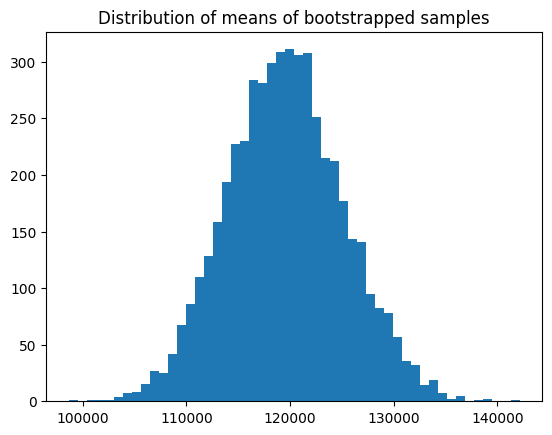

In [5]:
# visualizing the bootstrapped distribution
plt.hist(means_of_bstp, bins=50)
plt.title("Distribution of means of bootstrapped samples")
plt.show()

>The means of the 5K bootstrapped samples appear normally distributed.

>Notice that the mean of the bootstrapped means appears different than the hypothesized value($110K). 

In [6]:
# Calculating standard error
std_err = np.std(means_of_bstp, ddof=1)
std_err

np.float64(5598.919541502432)

NOTE: ideally, std_err is found using formula $SE = \frac{\sigma}{\sqrt{n}}$. The division by $\sqrt{n}$ is to "guess" how much the mean would vary if you took many more samples.

However in case of bootstrapped-sample, the"many more samples" are already simulated. Thus, division by $\sqrt{n}$ is not required.

### z-scores
>The z-score is a standardized measure that tells us how many standard deviations away from the mean a particular data point lies.

Before testing our hypothesis, we'll be standarding the values using z-scores.

Using a slightliy modified version of the z-score:
$z = \frac{\text{Sample stat} - \text{Hypothsized param value}}{\text{Standard error}}$

Note: that standard error $(SE = \frac{\sigma}{\sqrt{n}})$ quantifies the precision of a sample statistic (usually the mean) in representing the true population parameter.

In [7]:
# using variables to fit into above formula
print(f"The actual mean of population is = {np.round(mean_comp_sample,2)}\n")

print(f"Standard error (precision of sample mean) = {np.round(std_err,2)}\n")

# the hypothsized value being tested
hyp_mean_comp = 110000
print(f"Hypothesized compensation mean = {np.round(hyp_mean_comp,2)}\n")

# calculatng z-score
z_score = (mean_comp_sample - hyp_mean_comp) / std_err
print(f"Calculated z-score = {np.round(z_score,2)}")

The actual mean of population is = 119574.72

Standard error (precision of sample mean) = 5598.92

Hypothesized compensation mean = 110000

Calculated z-score = 1.71


>Thus ,we'll be working to understand whether the z-score (~1.71) is a high or low number
>
>i.e. Whether the sample statistic (mean) is close or far away from the hypothesized value.

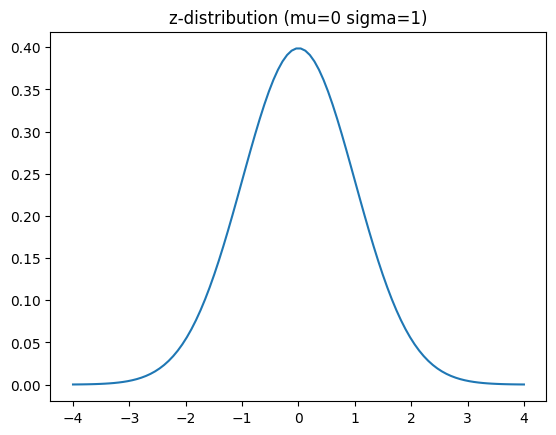

In [8]:
from scipy.stats import norm
mu=0
sigma=1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
y = norm.pdf(x, mu, sigma)
plt.title("z-distribution (mu=0 sigma=1)")
plt.plot(x,y)
plt.show()


In the `stackoverflow` dataset, `age_first_code_cut` classifies when the user first started programming.

Previous research: 35% of software devs started programming as children

This raises a question that can be answered using our current dataset -<br>
**_Does the sample provide evidence that a greater proportion of data scientists started programming as children?_**

A hypothesis test is a test of two competing hypotheses -- the Null hypothesis $(H_0)$ i.e. an existing idea and an Alternative hypothesis $(H_A)$ is the new 'challenger' idea.

>**The goal of hypothesis testing is to determine whether there is enough statistical evidence to reject the null hypothesis in favor of the alternate hypothesis.**

____
### p-values

The smaller the p-value, the stronger the evidence against the null hypothesis.

In below scenario: <br>
- $(H_0)$ : proportion of data scientists who started programming as children is 35%
- $(H_A)$ : proportion of data scientists who started programming as children is **greater than 35%**

Only one of the hypotheses can be true. $(H_0)$ is assumed to be initially true unless proven false -- in which case we reject it in favour of $(H_A)$.

In [9]:
stackoverflowdf["age_first_code_cut"].value_counts(normalize=True)

age_first_code_cut
adult    0.60858
child    0.39142
Name: proportion, dtype: float64

In [10]:
(stackoverflowdf["age_first_code_cut"]=="child").count()


np.int64(2261)

In [11]:
# assumed value
kidprog_hyp = 0.35

# Creating a list of bootstrapped-sampled means
kidprog_means = []

# taking 5K mean of bootstrapped samples
for i in range(5000):
    kidprog_means.append(
        np.mean(stackoverflowdf.sample(frac=1, replace=True)
                ["age_first_code_cut"]=="child"))

print(kidprog_means)

[np.float64(0.3940734188412207), np.float64(0.4024767801857585), np.float64(0.37195931003980537), np.float64(0.3993808049535604), np.float64(0.3931888544891641), np.float64(0.40203449800973023), np.float64(0.40645731977001326), np.float64(0.38832375055285273), np.float64(0.3622291021671827), np.float64(0.37549756744803187), np.float64(0.37947810703228657), np.float64(0.39274657231313576), np.float64(0.3998230871295887), np.float64(0.3847854931446263), np.float64(0.39053516143299427), np.float64(0.39584254754533393), np.float64(0.3949579831932773), np.float64(0.38699690402476783), np.float64(0.38390092879256965), np.float64(0.39097744360902253), np.float64(0.37770897832817335), np.float64(0.38390092879256965), np.float64(0.3847854931446263), np.float64(0.40513047324192836), np.float64(0.38832375055285273), np.float64(0.3940734188412207), np.float64(0.3878814683768244), np.float64(0.3847854931446263), np.float64(0.3936311366651924), np.float64(0.3993808049535604), np.float64(0.4042459088

In [12]:
# proportion of DS from the dataset who started coding as kids 
# part_child_sample_mean = (stackoverflowdf["age_first_code_cut"]=="child").mean()
part_child_sample_mean = np.mean(kidprog_means)

# The hypothesized significance level
kidprog_alpha = 0.05

# Standard error for stackoverflow["age_first_code"] column
kidprog_stderr = np.std(kidprog_means, ddof=1)

print(f"Avg. age of programmers who started coding as child = {part_child_sample_mean:.3f}\n")
print(f"Proposed hypothesized (mean) value = {kidprog_hyp}\n")
print(f"Considered significance value (alpha) = {kidprog_alpha}\n")
print(f"Bootsrap sample std (SE) = {kidprog_stderr}")

Avg. age of programmers who started coding as child = 0.392

Proposed hypothesized (mean) value = 0.35

Considered significance value (alpha) = 0.05

Bootsrap sample std (SE) = 0.010062496110584301


In [13]:
# calculating z-score
stckovrflw_zscore = (part_child_sample_mean - kidprog_hyp)/kidprog_stderr
print(f"z-score = {stckovrflw_zscore}")

z-score = 4.137776068412498


In [14]:
# calculating the p-value
from scipy.stats import norm
kidprog_pval = 1 - norm.cdf(stckovrflw_zscore, loc=0, scale=1)
print(f"The p-value is {kidprog_pval}")

The p-value is 1.7534418914499916e-05


In [15]:
# comparing with hypothesized value
kidprog_pval <= kidprog_alpha

np.True_

So p-value is less than hypothesized value.

> Thus , we reject $H_{0}$ in favour of $H_{A}$

i.e. the porportion of data scientists who started coding early on in their childhood is certainly greater than 35%.

### Confidence intervals

$\alpha$ of 0.05% means 95% confidence interval.

**False positive:** Actual correct hypothesis is $H_{0}$ but we supported $H_{A}$<br>
*This is called a Type I error*

**False negative:** Actual correct hypothesis is $H_{A}$ but we supported $H_{0}$<br>
*This is called a Type II error*

In [16]:
ci_low = np.quantile(kidprog_means, 0.025)

ci_high = np.quantile(kidprog_means, 0.975)

print(f"Confidence interval: ({ci_low:.3f}, {ci_high:.3f})")

Confidence interval: (0.372, 0.411)


>Since our hypothesized value (0.35) lies outside the 95% CI (0.372 – 0.411), we can reject the $H_{0}$ 

>The evidence strongly supports that more than 35% of data scientists started coding as children — our sample proportion of 39.1% is not due to chance.

In our case, it could happen that only the sample we chose had higher proportions of DS who began coding as a kid. The reality could different than our hypothesis ($H_{A}$).

So, despite $p \le \alpha$ & us rejecting $H_{0}$, it could be that there's a far smaller proportion of DS who'd started coding as a kid. Maybe we didn't consider a sufficiently large sample size.  Thus, its possible we made **a false positive error** or a **Type I error**.

____________
### Results of Hypothesis testing

For hypothesis tests and for criminal trials, there are two states of truth and two possible outcomes. 

Two combinations are correct test outcomes, and there are two ways it can go wrong.

**False positive:** Actual correct hypothesis is $H_{0}$ but we supported $H_{A}$<br>
*This is called a Type I error*

**False negative:** Actual correct hypothesis is $H_{A}$ but we supported $H_{0}$<br>
*This is called a Type II error*

_____
# Two-sample & ANOVA tests
## Two-sample t-test
>We compare Group A vs Group B independently

This is a two-sample independent t-test (also called an unpaired t-test) since each group is entirely separate -- there's one group of DS who started coding as kids & another group who started coding much later as adults. 

In below example , there's no natural pairing between any adult-group person and any child-group person.

>Question to be answered: *Are users who started coding earlier as kid compensated higher than those who started coding as adult?*

$H_{0}$: The mean compensation (in USD) **is the same** for those that coded first as a kid and those that coded first as an adult.<br>
This can be written as: $H_{0}$ : $\mu_{kid} = \mu_{adult}$  or  $H_{0}$ : $\mu_{kid} - \mu_{adult} = 0$<br>

$H_{A}$: The mean compensation (in USD) **is greater for those that coded first as a kid** as compared to those that coded first as an adult.<br>
This can be written as: $H_{0}$ : $\mu_{kid} > \mu_{adult}$  or  $H_{0}$ : $\mu_{kid} - \mu_{adult} > 0$<br>

In [17]:
stackoverflowdf["age_first_code_cut"].value_counts()

age_first_code_cut
adult    1376
child     885
Name: count, dtype: int64

In [18]:
stackoverflowdf.groupby("age_first_code_cut")["converted_comp"].mean().round(3)

age_first_code_cut
adult    111313.311
child    132419.571
Name: converted_comp, dtype: float64

>Now, it needs to be checked whether this difference in mean compensation of both groups is statistically significant OR if its due to sample variability.

______________________
### Performing t-tests
It is a statistical method used **to compare the means of two independent groups** to determine if there is a statistically significant difference between them. 

It determines if the observed difference between sample means is likely to reflect a true difference in the population, rather than just random sampling error.

General formula for 2-sampled t-test: $t= \frac{\text{difference in sample stats} - \text{difference in population stats}}{\text{standard error}}$  &nbsp; <br>where &nbsp; $SE_{diff}=\sqrt{\frac{s_{1}^{2}}{n_{1}}+\frac{s_{2}^{2}}{n_{2}}}$

but $H_{0}$ states that ${\text{difference in population stats}=0}$ , so formula for t-tests becomes:<br>
>$t= \frac{\text{difference in sample stats}}{\text{standard error}}$
<br>
<br>

For the above example,
$t=\frac{(\={x}_{\text{kid}}-\={x}_{\text{adult}})-(\mu _{\text{kid}}-\mu _{\text{adult}})}{S.E.(\={x}_{\text{kid}}-\={x}_{\text{adult}})}$ but for Null Hypothesis $H_{0}:\mu _{\text{kid}}-\mu _{\text{adult}}=0\quad \rightarrow \quad t=\frac{(\={x}_{\text{kid}}-\={x}_{\text{adult}})}{S.E.(\={x}_{\text{kid}}-\={x}_{\text{adult}})}$

So the final , expanded T-Statistic (using Sample Standard Deviation and Size):<br>
>$t=\frac{(\={x}_{\text{kid}}-\={x}_{\text{adult}})}{\sqrt{\frac{s_{\text{kid}}^{2}}{n_{\text{kid}}}+\frac{s_{\text{adult}}^{2}}{n_{\text{adult}}}}}$

In [19]:
# Calculating values as per formula
xbar =  stackoverflowdf.groupby('age_first_code_cut')['converted_comp'].mean()
xbar_ad = xbar.loc["adult"]
xbar_kd = xbar.loc["child"]

se = stackoverflowdf.groupby('age_first_code_cut')['converted_comp'].std()
se_ad = se.loc["adult"]
se_kd = se.loc["child"]

n = stackoverflowdf.groupby('age_first_code_cut')['converted_comp'].count()
nos_ad = n.loc["adult"]
nos_kd = n.loc["child"]

print(f"Sample means for each group: {xbar}\n")
print(f"Standard errors for each group: {se}\n")
print(f"Sample size for each group: {n}")

Sample means for each group: age_first_code_cut
adult    111313.311047
child    132419.570621
Name: converted_comp, dtype: float64

Standard errors for each group: age_first_code_cut
adult    271546.521729
child    255585.240115
Name: converted_comp, dtype: float64

Sample size for each group: age_first_code_cut
adult    1376
child     885
Name: converted_comp, dtype: int64


In [20]:
# Finding t-stat based on above values
numrtr = xbar_kd - xbar_ad
dnmtr = np.sqrt((se_kd**2/nos_kd) + (se_ad**2/nos_ad))

t_stat = numrtr / dnmtr

print(f"t-stat = {t_stat}")

t-stat = 1.8699313316221844


### Calculating p-values from t-statistics

The t-statistics follows a t-distribution -- whose tails are fatter than those of a null distribution. This thickness of tails in t-distribution can be controlled by **degrees of freedom $(df)$**. 

As $df$ increases & approaches $\infty$, it very closely represents a normal distribution curve. Degrees of freedom are the maximum number of logically independent values in the data sample.

T-statistic is useful to calculate p-value when sample size is small & population variance is not known.

In above example: 
$df = n_{kid} - n_{adult} - 2$ <br>
_(-2 because its going to be a 2-sample t-test)_

In [21]:
# calculating degrees of freedom
dof = nos_kd + nos_ad -2

print(f"degrees of freedom for above example = {dof}")

degrees of freedom for above example = 2259



Now coming to above example:<br>
$H_{0}$: The mean compensation (in USD) **is the same** for those that coded first as a kid and those that coded first as an adult<br>
$H_{A}$: The mean compensation (in USD) **is greater for those that coded first as a kid** as compared to those that coded first as an adult.

Assume significance value ($\alpha$) = 0.1. So $H_{0}$ rejected if $p \le \alpha$.

In [22]:
# consider alpha value
new_alpha = 0.1

# right-tailed test p-value , using t-distribution
from scipy.stats import t
pvalue_tstats = 1 - t.cdf(t_stat, df=dof)
print(f"p-value using t-stats = {pvalue_tstats}")

p-value using t-stats = 0.030811302165157595


In [23]:
# comparing with new alpha
pvalue_tstats <= new_alpha

np.True_

>Since p-value is less than alpha value, thus we reject $H_{0}$ in favour of $H_{A}$

In [24]:
print(f"p-value calculated using z-score: {kidprog_pval}\n")
print(f"p-value calculated using t-statistics: {pvalue_tstats}")

p-value calculated using z-score: 1.7534418914499916e-05

p-value calculated using t-statistics: 0.030811302165157595


This also shows that p-value calculated using t-statistics is much greater than one calculated using z-score.

In [25]:
stackoverflowdf.columns

Index(['respondent', 'main_branch', 'hobbyist', 'age', 'age_1st_code',
       'age_first_code_cut', 'comp_freq', 'comp_total', 'converted_comp',
       'country', 'currency_desc', 'currency_symbol',
       'database_desire_next_year', 'database_worked_with', 'dev_type',
       'ed_level', 'employment', 'ethnicity', 'gender', 'job_factors',
       'job_sat', 'job_seek', 'language_desire_next_year',
       'language_worked_with', 'misc_tech_desire_next_year',
       'misc_tech_worked_with', 'new_collab_tools_desire_next_year',
       'new_collab_tools_worked_with', 'new_dev_ops', 'new_dev_ops_impt',
       'new_ed_impt', 'new_job_hunt', 'new_job_hunt_research', 'new_learn',
       'new_off_topic', 'new_onboard_good', 'new_other_comms', 'new_overtime',
       'new_purchase_research', 'purple_link', 'newso_sites', 'new_stuck',
       'op_sys', 'org_size', 'platform_desire_next_year',
       'platform_worked_with', 'purchase_what', 'sexuality', 'so_account',
       'so_comm', 'so_part_freq'

## Paired t-tests
>Helps answer _“Did the same entity change between two conditions?”_ . We compare _Before vs After_ scenarios.

Paired t-test is performed for paired-data. A tyical paired dataset could be:
- One-to-one correspondence: Every observation in Sample A is directly matched to a specific observation in Sample B.
- Same subject/source:  the pairs often come from measuring the same individual twice (before/after test scores of student X etc.)


Below dataset is state-wise voting percentage for a political party. Vote shares in each state are shown in 2 columns for 2008 & 2012 elections.

>We need to find : was vote share lower in 2008 than in 2012?

**Null Hypothesis:** That there was no change in the vote share from 2008-2012<br>
So  $H_{0}$: $\mu_{2008} - \mu_{2012} = 0$

**Alternate Hypothesis:** Vote share in 2008 was lower than 2012<br>
$H_{A}$: $\mu_{2008} - \mu_{2012} < 0$

The t-statistic formula is:

$t = \frac{\bar{x}_{diff} - \mu_{diff}}{\sqrt{\frac{(s_{diff})^2}{n_{diff}}}}$

Consider $\alpha$ = 0.1

In [26]:
main_df = pd.read_feather('./datasets/repub_votes_potus_08_12.feather')
main_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   state             100 non-null    str    
 1   county            100 non-null    str    
 2   repub_percent_08  100 non-null    float64
 3   repub_percent_12  100 non-null    float64
dtypes: float64(2), str(2)
memory usage: 4.7 KB


In [27]:
main_df.head()

,state,county,repub_percent_08,repub_percent_12
0,Alabama,Hale,38.957877,37.139882
1,Arkansas,Nevada,56.726272,58.983452
2,California,Lake,38.896719,39.331367
3,California,Ventura,42.923190,45.250693
4,Colorado,Lincoln,74.522569,73.764757


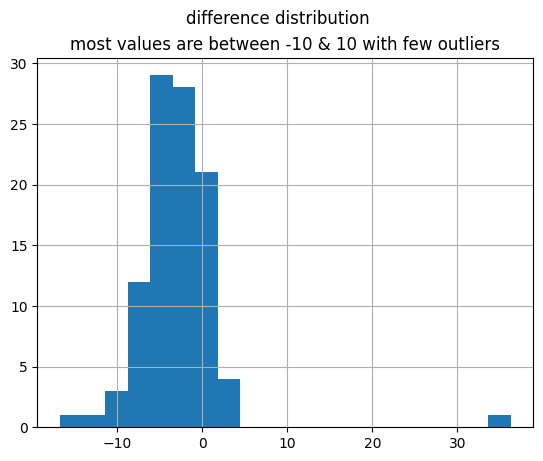

In [28]:
main_df['diff'] = main_df['repub_percent_08'] - main_df['repub_percent_12']

# plotting the difference in vote shares
main_df['diff'].hist(bins=20)
plt.suptitle('difference distribution')
plt.title('most values are between -10 & 10 with few outliers')
plt.show()

In [29]:
# calculating men of the differences
xbar_diff = main_df['diff'].mean()

# calculating the n_diff
n_diff = len(main_df)

# calculating s_diff
s_diff = main_df['diff'].std()

# calculating t-stat
t_stat = (xbar_diff - 0) / np.sqrt(s_diff**2/n_diff)
print(f"t-stat value = {t_stat}\n")

# calculating degrees of freedom
dof = n_diff - 1
print(f"degrees of freedom = {dof}\n")

# Defining alpha value
alpha_voteshare = 0.1
print(f"significance level(alpha) = {alpha_voteshare}")

t-stat value = -5.601043121928489

degrees of freedom = 99

significance level(alpha) = 0.1


In [30]:
# finding p-value for left-tailed t-test:
from scipy.stats import t
pvalue_voteshare = t.cdf(t_stat, df=dof) 
print(f"p-value for above example ={pvalue_voteshare}")

# comparing p-value with defined alpha value
pvalue_voteshare <= alpha_voteshare

p-value for above example =9.572537285272411e-08


np.True_

Since p-vlaue is much smaller than the defined $\alpha$, the $H_{0}$ is rejected in favour of the $H_{A}$ - i.e. The voteshare of the candidate in 2008 was indeed smaller than that in 2012.

In [31]:
# Alternative method to find t-stat & p-value
from scipy.stats import ttest_rel

ttest_rel(main_df['repub_percent_08'], main_df['repub_percent_12'], alternative='less')


TtestResult(statistic=np.float64(-5.601043121928488), pvalue=np.float64(9.572537285272479e-08), df=np.int64(99))

### `pingouin`- a better alternative for t-testing
The Pingouin library is commonly used for paired t-tests in Python, favored for providing comprehensive results in a single line of code. https://pingouin-stats.org/



In [32]:
import pingouin as pg

#Performing a left-tailed t-test
pg.ttest(x=main_df['diff'], y=0, alternative='less')

,T,dof,alternative,p_val,CI95,cohen_d,power
T_test,-5.601043,99,less,9.572537e-08,"[-inf, -2.02]",0.560104,0.999955


In [33]:
# Another variation - passing concerned columns directly
pg.ttest(x=main_df['repub_percent_08'], y=main_df['repub_percent_12'], paired=True, alternative='less')


,T,dof,alternative,p_val,CI95,cohen_d,power
T_test,-5.601043,99,less,9.572537e-08,"[-inf, -2.02]",0.217364,0.696338


_____
## ANOVA test
ANalysis Of VAriance test -- used to test significance of differences between multiple (>2) groups.<br>
_(could be used for both -- unpaired or paired data)_


Considering following example:<br>
>We try to answer: if mean annual compensation is different for different levels of job satisfaction?

On plotting the compensation stats for each satisfaction level, the 'Very satisfied' category seems to have slightly higher compensations overall.

>However, it needs to be checked how significant this difference is relative to the other satisfaction levels



Consider $\alpha = 0.2$ 

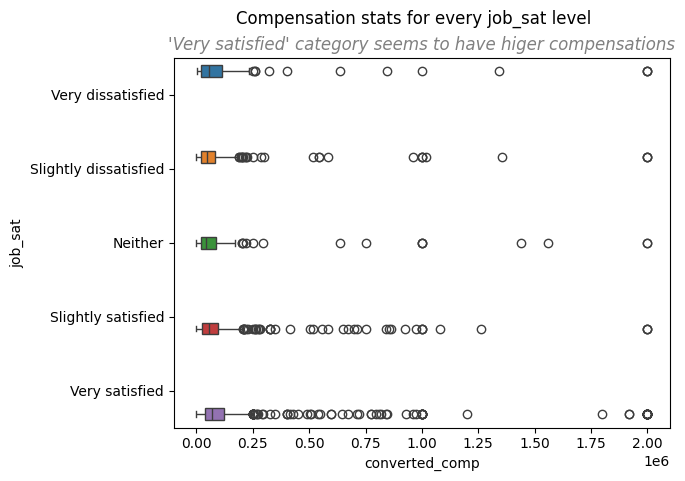

In [34]:
sns.boxplot(data=stackoverflowdf,x='converted_comp', y= 'job_sat', hue='job_sat')
plt.suptitle("Compensation stats for every job_sat level")
plt.title("'Very satisfied' category seems to have higer compensations", fontdict={'color':'grey', 'style':'italic'})
plt.show()

### Using `pingouin` library's `.anova` method
p-value is stored in the `p_unc` (p-value uncorrected) column.

If we try to apply two-sample t-test to each pair, significance level $\alpha$ applies to each test, and the actual error rate would explode with each additional test. This error rate is basically the probability of at least one false positive. 

In below example, this probability rate of atleast one false positive would become near-certain ($1 - 0.2^3 = 0.99$)  

**ANOVA solves this by testing all groups simultaneously in one test.**

ANOVA uses F-statistic: $F=\frac{\text{Between - group variance}}{\text{Within - group variance}}$

Large F  →  groups differ more than random noise  →  small p-value  →  reject H₀<br>
Small F  →  group differences explained by noise  →  large p-value  →  fail to reject H₀


In [35]:
# defining significance value
alpha_jobsat = 0.2

# using the anova method of the pingouin library
anova_result = pg.anova(data=stackoverflowdf, dv='converted_comp', between='job_sat')
anova_result

,Source,ddof1,ddof2,F,p_unc,np2
0,job_sat,4,2256,4.480485,0.001315,0.007882


In [36]:
anova_result['p_unc'] <= 0.2

0    True
Name: p_unc, dtype: bool

>But result of the `.anova` only shows there is significance difference in compensation levels amongst atleast 2 job_sat levels , but doesn;t indicate which ones.

### Post-hoc Testing:

If done manually, it will lengthen the time taken to which two columns have the difference. The steps will only increase in complexity if th no. of betwee-subject factors (categories/ sample groups) increases.

To determine exactly which job_sat levels we use the `pairwise_tests()` method. This method runs all the hypothesis tests in one go & presents the 

In [37]:
pairwise_test_result = pg.pairwise_tests(data=stackoverflowdf, dv='converted_comp',
                  between='job_sat', padjust='none')
pairwise_test_result

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,BF10,hedges
0,job_sat,Very dissatisfied,Slightly dissatisfied,False,True,1.129951,247.570187,two-sided,0.259590,0.197,0.119131
1,job_sat,Very dissatisfied,Neither,False,True,0.545948,321.165726,two-sided,0.585481,0.135,0.058537
2,job_sat,Very dissatisfied,Slightly satisfied,False,True,1.243665,187.153329,two-sided,0.215179,0.208,0.145624
3,job_sat,Very dissatisfied,Very satisfied,False,True,-0.747379,221.666205,two-sided,0.455627,0.126,-0.063479
4,job_sat,Slightly dissatisfied,Neither,False,True,-0.602209,367.730081,two-sided,0.547406,0.118,-0.055707
5,job_sat,Slightly dissatisfied,Slightly satisfied,False,True,0.038264,569.926329,two-sided,0.969491,0.074,0.002719
6,job_sat,Slightly dissatisfied,Very satisfied,False,True,-3.076222,821.303063,two-sided,0.002166,7.43,-0.173247
7,job_sat,Neither,Slightly satisfied,False,True,0.700752,258.204546,two-sided,0.484088,0.114,0.068513
8,job_sat,Neither,Very satisfied,False,True,-1.662901,328.326639,two-sided,0.097286,0.337,-0.120115
9,job_sat,Slightly satisfied,Very satisfied,False,True,-4.009935,1478.622799,two-sided,0.000064,158.564,-0.192931


In [38]:
# finding job_sat combinations having p-values < alpha(0.2)
pairwise_test_result[pairwise_test_result['p_unc']<=0.2]

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,BF10,hedges
6,job_sat,Slightly dissatisfied,Very satisfied,False,True,-3.076222,821.303063,two-sided,0.002166,7.43,-0.173247
8,job_sat,Neither,Very satisfied,False,True,-1.662901,328.326639,two-sided,0.097286,0.337,-0.120115
9,job_sat,Slightly satisfied,Very satisfied,False,True,-4.009935,1478.622799,two-sided,0.000064,158.564,-0.192931


>Differences in compensation levels are most significant (than the defined $\alpha$) among the job_sat group combinations

These are the job_sat levels having p-value < $\alpha$. However, ANOVA only says "at least one group differs". It does NOT say which group(s).

### Bonferroni correction
To find which specific pairs differ, you need post-hoc tests — and this is exactly where Bonferroni correction comes in. **Bonferroni correction distributes that error budget equally across all comparisons.**

If we increase no. of groups (samples) then no. of pairs also increases drastically. Running multiple pairwise hypothesis tests inflates the false positive rate — the same problem as running multiple t-tests.

### How Bonferroni correction works?
It makes the threshold stricter in proportion to how many comparisons you're making.

All possible pairs for $k$ groups = $\frac{k(k-1)}{2}$ 

If $\alpha$= 0.2%, Bonferroni correction divides it equally into  ${\alpha}/ ({\text{no. of splits as per Bonferroni's correction}}) = \frac{0.2}{6}$ . <br>
This $\alpha_{adj}$ value = 0.033, is the adjusted $\alpha$ value against which each pair's p-value is evaluated.


For e.g. 4 groups , we'll be making $\frac{4(4 - 1)}{2} $= 6 pairs



In [39]:
# Applying the Bonferroni correction
bonf_pairwise_test_result = pg.pairwise_tests(data=stackoverflowdf, dv='converted_comp',
                  between='job_sat', padjust='bonf')

bonf_pairwise_test_result

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,job_sat,Very dissatisfied,Slightly dissatisfied,False,True,1.129951,247.570187,two-sided,0.259590,1.000000,bonf,0.197,0.119131
1,job_sat,Very dissatisfied,Neither,False,True,0.545948,321.165726,two-sided,0.585481,1.000000,bonf,0.135,0.058537
2,job_sat,Very dissatisfied,Slightly satisfied,False,True,1.243665,187.153329,two-sided,0.215179,1.000000,bonf,0.208,0.145624
3,job_sat,Very dissatisfied,Very satisfied,False,True,-0.747379,221.666205,two-sided,0.455627,1.000000,bonf,0.126,-0.063479
4,job_sat,Slightly dissatisfied,Neither,False,True,-0.602209,367.730081,two-sided,0.547406,1.000000,bonf,0.118,-0.055707
5,job_sat,Slightly dissatisfied,Slightly satisfied,False,True,0.038264,569.926329,two-sided,0.969491,1.000000,bonf,0.074,0.002719
6,job_sat,Slightly dissatisfied,Very satisfied,False,True,-3.076222,821.303063,two-sided,0.002166,0.021659,bonf,7.43,-0.173247
7,job_sat,Neither,Slightly satisfied,False,True,0.700752,258.204546,two-sided,0.484088,1.000000,bonf,0.114,0.068513
8,job_sat,Neither,Very satisfied,False,True,-1.662901,328.326639,two-sided,0.097286,0.972864,bonf,0.337,-0.120115
9,job_sat,Slightly satisfied,Very satisfied,False,True,-4.009935,1478.622799,two-sided,0.000064,0.000638,bonf,158.564,-0.192931


After applying the correction , we see only 2 pairs of job_sats having significant differences 

In [40]:
bonf_pairwise_test_result['p_corr'].nsmallest(2)

9    0.000638
6    0.021659
Name: p_corr, dtype: float64

___
## Alternate example for ANOVA test

In [41]:
stackoverflowdf['ed_level'].value_counts()

ed_level
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       961
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          743
Other doctoral degree (Ph.D., Ed.D., etc.)                                            346
Some college/university study without earning a degree                                125
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)     27
Professional degree (JD, MD, etc.)                                                     18
Associate degree (A.A., A.S., etc.)                                                    16
I never completed any formal education                                                  5
Primary/elementary school                                                               5
Name: count, dtype: int64

In [42]:
stackoverflowdf.groupby("ed_level")['converted_comp'].mean()

ed_level
Associate degree (A.A., A.S., etc.)                                                    78251.375000
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          124061.982503
I never completed any formal education                                                 55405.000000
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       106729.924037
Other doctoral degree (Ph.D., Ed.D., etc.)                                            139038.855491
Primary/elementary school                                                             231218.400000
Professional degree (JD, MD, etc.)                                                     96393.055556
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)    194886.777778
Some college/university study without earning a degree                                115903.904000
Name: converted_comp, dtype: float64

________
## One-sample proportion Tests

z-score = $\frac{\bar{p} - p_0}{\sqrt{{p_0(1-p_0)}/{n}}} = \frac{\bar{p} - p_{0}}{SE(\bar{p})}$ &nbsp; where 

$p$ : population proportion (unknown)<br>
$\bar{p}$ : sample proportion<br>
$p_{0}$ : hypothesized proportion

In a z-score $(\frac{\bar{x} - \text{hypothetical value}}{S.E.})$,  the test statistic for proportion(s) has only one estimate of a parameter -- the sample deviation in SE $(\frac{\sigma}{\sqrt{n}})$.

Whereas, in t-statistic $(t = \frac{\bar{x}_{diff} - \mu_{diff}}{\sqrt{(s_{diff})^2/{n_{diff}}}})$ uses  two estimated values -- assumed population parameter(mean) AND also the Std Deviation $(s)$ in denominator -- which increases the uncertainity of its results.

>This means that z-score is a more reliable statistic for one-sample tests since it has less uncertainity. 

Z-distributions are used for proportion tests because the uncertainty is lower, **given that only one parameter ($\bar{p}$) is estimated from the sample**, unlike in t-tests where both the mean and standard deviation are estimated, increasing uncertainty.

**Example:** Hypothesis : Half of the stackoverflow users are under 30:<br>
$H_{0}$: proportion of users under 30 = 0.5 &nbsp; &nbsp; $H_{A}$: proportion of users under 30 $\ne$ 0.5



In [43]:
stackoverflowdf['age_cat'].value_counts(normalize=True)

age_cat
Under 30       0.535604
At least 30    0.464396
Name: proportion, dtype: float64

We observe from dataset statistics, that proportion of users under 30 is slightly more than 50%. 

>Next we perform a one-sample t-test to determine how statistically significant this difference in proportion is.

In [44]:
# defining significance level (alpha)
agecat_alpha = 0.01

# Hypothesized value (half of the userbase is below 30yrs)
agecat_p0 = 0.5

# population /sample statistic (mean) for users under 30yrs
agecat_pbar = (stackoverflowdf['age_cat']=='Under 30').mean().round(3)

# population size
agecat_n = len(stackoverflowdf)

print(f"Significance level (alpha) defined = {agecat_alpha}")
print(f"Hypothesized value = {agecat_p0}")
print(f"sample statistic (mean) for users under 30yrs = {agecat_pbar}")
print(f"Popultion size n = {agecat_n}\n")

# Calculating z-score for one-sampel proportion
agecat_zscore = (agecat_pbar - agecat_p0)/ np.sqrt(agecat_p0*(1 - agecat_p0)/agecat_n)
print(f"z-score = {agecat_zscore}")


Significance level (alpha) defined = 0.01
Hypothesized value = 0.5
sample statistic (mean) for users under 30yrs = 0.536
Popultion size n = 2261

z-score = 3.4235981072550006


**NOTE:** in this case, we are solving for a two-tailed hypothesis (we're checking whether the test statistic lies in either tail).

In [47]:
# We are solving for two-tailed test
agecat_pvalue = 2*(1 - norm.cdf(agecat_zscore))
print(f"p=-value for example = {agecat_pvalue}")

p=-value for example = 0.0006179794043528197


In [46]:
agecat_pvalue <= agecat_p0

np.True_

>Thus, we reject the null hypothesis that 50% of users are under 30. 

_____
## Two-sample proportion tests
>We want to test whether proportion of hobbyists users is equal for those under 30 as well as $\ge$ 30.

$H_0$: Proportion of hobbyists is **same for both** - below 30 as well as atleast/above 30 yrs of age. $H_0 : p_{\ge 30} - p_{<30}=0 $


$H_A$: Proportion of hobbyists is **different for both** - below 30 as well as atleast/above 30 yrs of age. $H_A : p_{\ge 30} - p_{<30}\ne 0 $

So , we'll be performing a two-tailed test.  Consider $\alpha = 0.05$

### z-score for proportion test:
General formuls of z-score : $z = \frac{ \text{sampled statistic} - \text{hypothesized value}}{SE}$ &nbsp; ,in this example $z = \frac{(p_{\ge 30} - p_{<30}) - 0}{SE(p_{\ge 30} - p_{<30})}$


In [51]:
stackoverflowdf.groupby("hobbyist")['age_cat'].value_counts(normalize=True)

hobbyist  age_cat    
No        At least 30    0.556075
          Under 30       0.443925
Yes       Under 30       0.557010
          At least 30    0.442990
Name: proportion, dtype: float64